# Analysing alpha-values over different seeds

This notebook is used to gain insights into how varying alpha values changes the dynamics of the problem and influences decision making

It is structured as follows:
1) Initial setup, imports and loading of data
2) Demand patterns and state insight
3) Trip requests
3) Failed events hourly patterns
4) Vehicle activity decision insights and time allocation
5) Comparison of alpha values



# 1 Initial setup, imports and loading of data

In [764]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gzip
import json
import folium
import numpy as np
import matplotlib.ticker as ticker

In [765]:
# --- 1. SETUP PATHS ---
current_path = Path(
    r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\rough_estimates"
)
seed_path = Path(
   # r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\Seed_results"
   r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\rough_estimates"
)

# Force the use of Seed_results since we know the files are there
results_dir_root = seed_path

instance_path = r"C:\Users\Minamsj\FOMOsim\instances\TD_W34_old.json.gz"

# --- 2. CONFIGURATION ---
alpha_value = 0.25
alpha_str = f"{alpha_value:.3f}"

# SELECT MODE HERE: 1, 2, or "average"
selection_mode = 1

# Function to get result file based on kind and seed
def get_result_file(kind: str, seed: int) -> Path:
    pattern = f"*fullweek_{alpha_str}_results_{kind}_seed_{seed}.csv"
    matches = list(results_dir_root.glob(pattern))
    
    if not matches:
        raise FileNotFoundError(f"No file found matching pattern: {pattern}")
    if len(matches) > 1:
        print(f"Warning: multiple files found for pattern {pattern}, using first:\n{matches[0]}")
    return matches[0]

# --- 3. LOAD DATA FOR SEED 1 ---
print("Loading Seed 1...")
vehicle_df_s1 = pd.read_csv(get_result_file("vehicle_visits", seed=1))
hourly_data_s1 = pd.read_csv(get_result_file("hourly", seed=1))
station_hourly_activity_df_s1 = pd.read_csv(get_result_file("station_hourly", seed=1))
trip_requests_df_s1 = pd.read_csv(get_result_file("trip_requests", seed=1))

# --- 4. LOAD DATA FOR SEED 2 ---
"""print("Loading Seed 2...")
vehicle_df_s2 = pd.read_csv(get_result_file("vehicle_visits", seed=2))
hourly_data_s2 = pd.read_csv(get_result_file("hourly", seed=2))
station_hourly_activity_df_s2 = pd.read_csv(get_result_file("station_hourly", seed=2))
trip_requests_df_s2 = pd.read_csv(get_result_file("trip_requests", seed=2))"""

# --- 5. SELECTION LOGIC (1, 2, or Average) ---
if selection_mode == 1:
    print(f"--> Mode: Analyzing Seed 1 Only")
    hourly_data = hourly_data_s1
    vehicle_df = vehicle_df_s1
    trip_requests_df = trip_requests_df_s1
    station_hourly_activity_df = station_hourly_activity_df_s1
    source_label = "Seed 1"

elif selection_mode == 2:
    print(f"--> Mode: Analyzing Seed 2 Only")
    hourly_data = hourly_data_s2
    vehicle_df = vehicle_df_s2
    trip_requests_df = trip_requests_df_s2
    station_hourly_activity_df = station_hourly_activity_df_s2
    source_label = "Seed 2"

elif selection_mode == "average":
    print(f"--> Mode: Analyzing Average (Seed 1 & Seed 2)")
    
    # Calculate average for hourly data
    hourly_data = hourly_data_s1.copy()
    numeric_cols = hourly_data.select_dtypes(include='number').columns
    hourly_data[numeric_cols] = (hourly_data_s1[numeric_cols] + hourly_data_s2[numeric_cols]) / 2
    
    # Calculate average for station hourly data
    station_hourly_activity_df = station_hourly_activity_df_s1.copy()
    numeric_cols_station = station_hourly_activity_df.select_dtypes(include='number').columns
    station_hourly_activity_df[numeric_cols_station] = (station_hourly_activity_df_s1[numeric_cols_station] + station_hourly_activity_df_s2[numeric_cols_station]) / 2

    # For event logs, we concatenate them (averaging logs isn't possible)
    vehicle_df = pd.concat([vehicle_df_s1, vehicle_df_s2]) 
    trip_requests_df = pd.concat([trip_requests_df_s1, trip_requests_df_s2])
    
    source_label = "Average (S1 & S2)"

# --- 6. LOAD STATION MAP DATA ---
with gzip.open(instance_path, "rt") as f:
    data = json.load(f)

stations_df = pd.DataFrame(data["stations"])
stations_df[["lat", "lon"]] = stations_df["location"].apply(pd.Series)

Loading Seed 1...
--> Mode: Analyzing Seed 1 Only


In [766]:
# values used in the plots and analysis
plt.rcParams.update({
    'figure.figsize': (16, 8),
})

value_size = 13
font_size = 15

## 1.1 State overview

### Seed 1

In [767]:
alpha_summary = hourly_data.agg(
    {
        "Maintenance Time (minutes)": "sum",
        "Maintenance Violations": "sum",
        "Maintenance Starvations": "sum",
        "Bike Starvations": "sum",
        "Starvations": "sum",
        "Bike Pickups": "sum",
        "Bike Deliveries": "sum",
    }
).reset_index()

alpha_summary.columns = ["Metric", "Value"]

print(f"\nAlpha = {alpha_value} ({alpha_str}) | Mode: {selection_mode}")
print(alpha_summary.to_string(index=False))

# --- 8. PRINT FILE PATHS USED ---
print("\n" + "="*50)
print("FILES USED:")

if selection_mode == "average":
    # If average, we must show files for BOTH seeds
    print("--- Seed 1 Files ---")
    print(f"Vehicle visits: {get_result_file('vehicle_visits', seed=1)}")
    print(f"Hourly data:    {get_result_file('hourly', seed=1)}")
    print(f"Station hourly: {get_result_file('station_hourly', seed=1)}")
    print(f"Trip requests:  {get_result_file('trip_requests', seed=1)}")
    
    print("\n--- Seed 2 Files ---")
    print(f"Vehicle visits: {get_result_file('vehicle_visits', seed=2)}")
    print(f"Hourly data:    {get_result_file('hourly', seed=2)}")
    print(f"Station hourly: {get_result_file('station_hourly', seed=2)}")
    print(f"Trip requests:  {get_result_file('trip_requests', seed=2)}")

else:
    # If selection_mode is 1 or 2, treat it as the 'seed'
    seed = selection_mode
    print(f"Vehicle visits: {get_result_file('vehicle_visits', seed=seed)}")
    print(f"Hourly data:    {get_result_file('hourly', seed=seed)}")
    print(f"Station hourly: {get_result_file('station_hourly', seed=seed)}")
    print(f"Trip requests:  {get_result_file('trip_requests', seed=seed)}")
    
print("="*50)


Alpha = 0.25 (0.250) | Mode: 1
                    Metric   Value
Maintenance Time (minutes) 1364.04
    Maintenance Violations    2.00
   Maintenance Starvations   90.00
          Bike Starvations  996.00
               Starvations 1086.00
              Bike Pickups 1335.00
           Bike Deliveries 1324.00

FILES USED:
Vehicle visits: C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\rough_estimates\sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_0.250_results_vehicle_visits_seed_1.csv
Hourly data:    C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\rough_estimates\sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_0.250_results_hourly_seed_1.csv
Station hourly: C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\rough_estimates\sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_0.250_results_station_hourly_seed_1.csv
Trip requests:  C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\rough_estim

# 2 Demand patterns and state insight

In [768]:
# print the instance path used
print(f"Instance used: {instance_path}")

# print number of stations, vehicles used, number of bikes
print(f"Number of vehicles in instance: {vehicle_df['Vehicle ID'].nunique()}")
print(f"Number of stations in instance: {len(stations_df)}")      


Instance used: C:\Users\Minamsj\FOMOsim\instances\TD_W34_old.json.gz
Number of vehicles in instance: 1
Number of stations in instance: 67


## 2.1 Average demand per hour for the simulation horizon

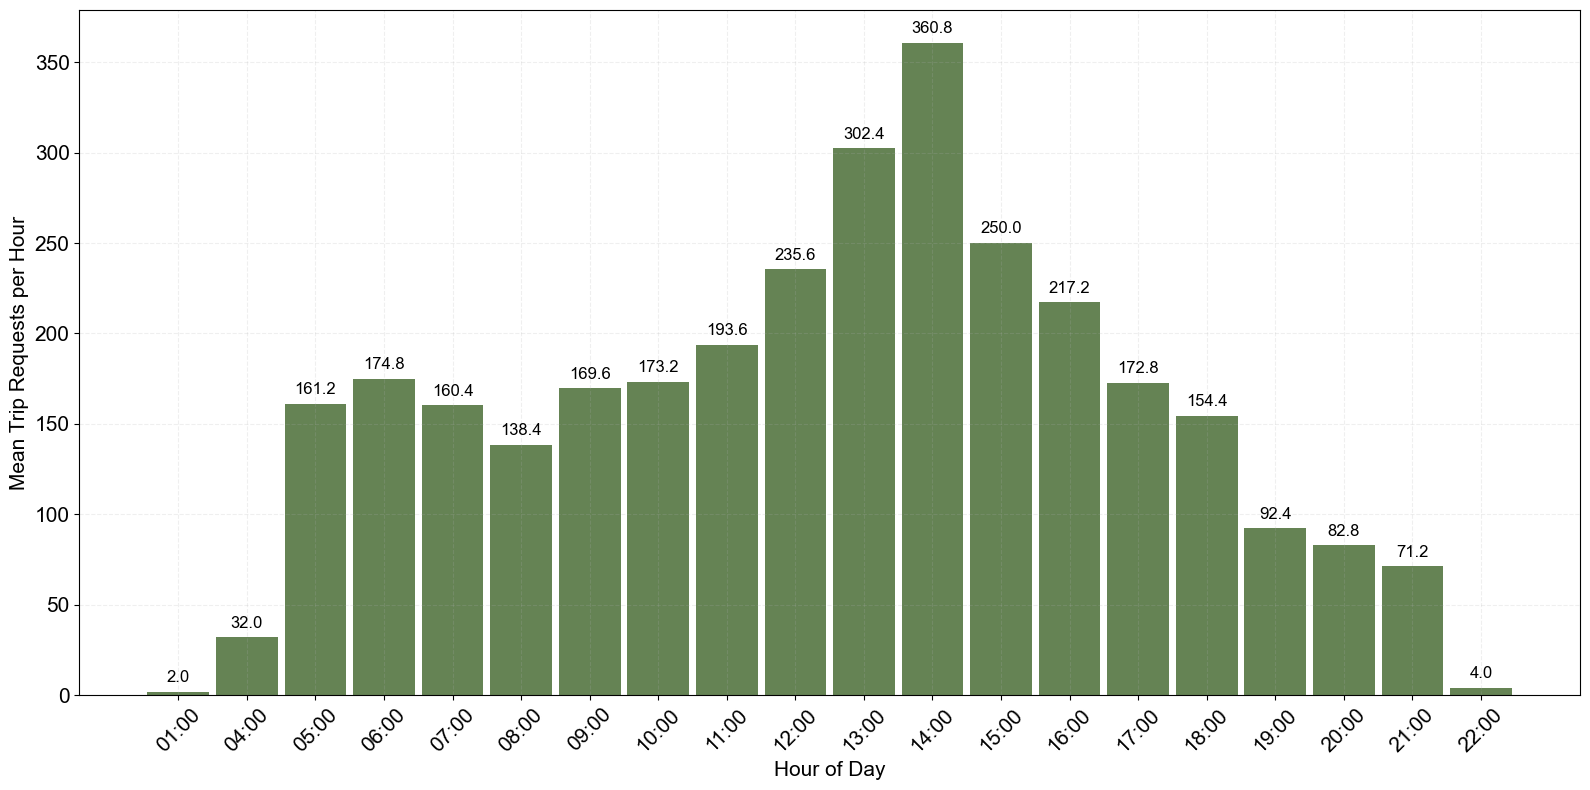

In [769]:
# 1. Count requests for each (Day, Hour) pair
demand_by_day_hour = (
    trip_requests_df.groupby(["Day", "Hour"])
    .size()
    .reset_index(name="Requests")
)

# 2. Compute mean requests per hour across days
mean_hourly_demand = (
    demand_by_day_hour.groupby("Hour")["Requests"]
    .mean()
    .reset_index()
)

hours = mean_hourly_demand["Hour"].tolist()
demand_vals = mean_hourly_demand["Requests"].tolist()

# Format x-axis labels as HH:00
hour_labels = [f"{int(h):02d}:00" for h in hours]

plt.figure()

bar_color = "#658354"   # change to whatever hex you want (e.g. "#ff5733")

plt.bar(hour_labels, demand_vals, color=bar_color, alpha=1.0, width=0.9)

plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Trip Requests per Hour", fontsize=font_size)

# Threshold for determining if bar is "too low"
threshold = 0.10 * max(demand_vals)

# Label values on bars
for h, v in zip(hour_labels, demand_vals):
    """if v >= threshold:
        # Place label INSIDE the bar
        plt.text(h, v * 0.5,
                 f"{v:.1f}",
                 ha='center', va='center',
                 color='white', fontsize=value_size-1, fontweight='bold')
    else:"""
    # Place label ABOVE the bar
    plt.text(h, v + threshold * 0.1,
                f"{v:.1f}",
                ha='center', va='bottom',
                color='black', fontsize=value_size-1)

plt.yticks(fontsize=font_size)
plt.xticks(rotation=45, fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)
plt.savefig("mean_trip_requests_per_hour.svg")

plt.tight_layout()
plt.show()


## 2.2 Demand across all hours

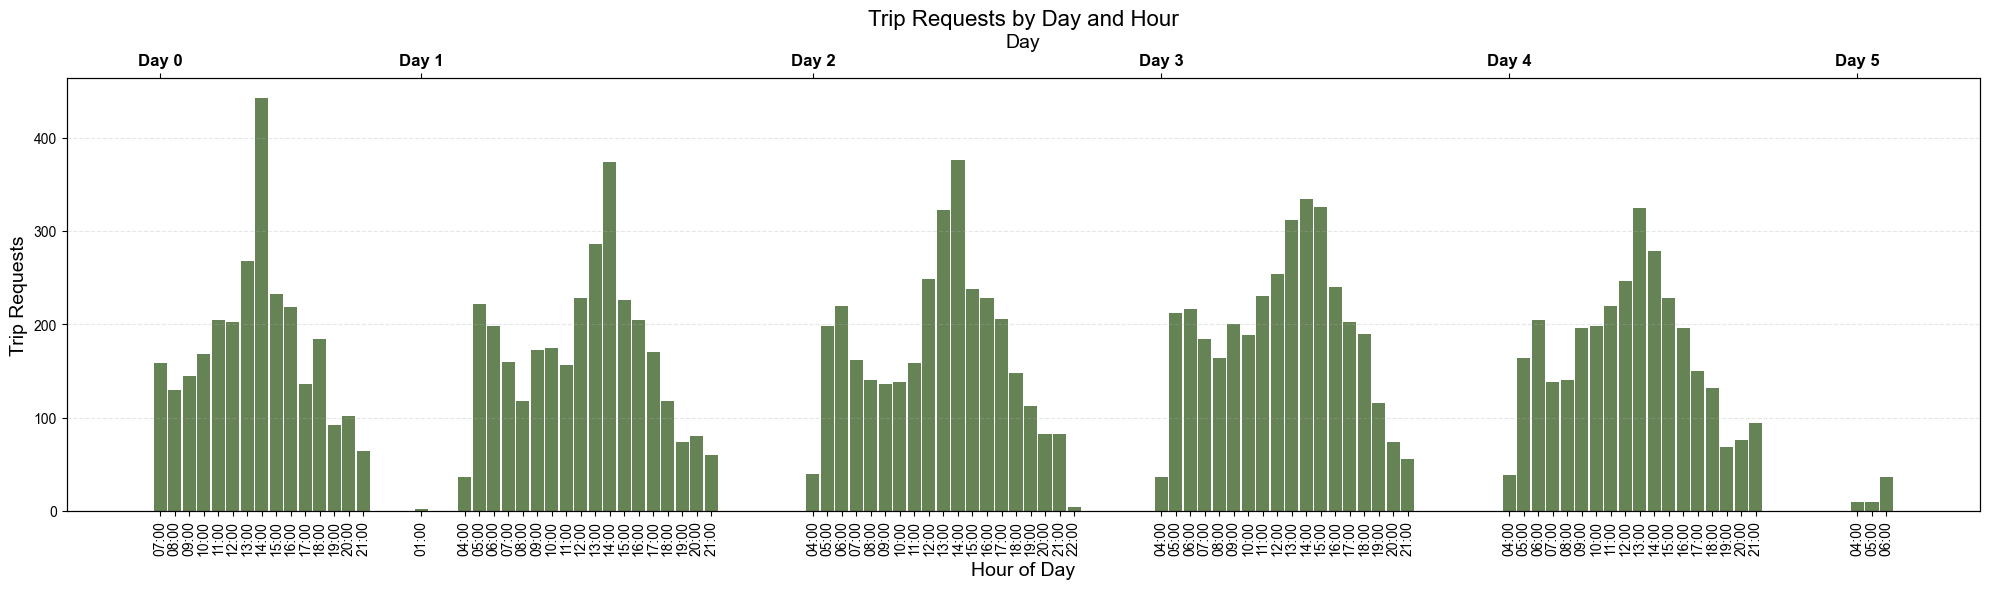

In [770]:

# --------------------------------------------------------
# 1. Count trip requests for each (Day, Hour) pair
# --------------------------------------------------------
demand_by_day_hour = (
    trip_requests_df.groupby(["Day", "Hour"])
    .size()
    .reset_index(name="Requests")
)

# Ensure sorting (important for correct x-axis order)
demand_by_day_hour = demand_by_day_hour.sort_values(["Day", "Hour"])

# --------------------------------------------------------
# 2. Prepare flattened index for plotting
# --------------------------------------------------------
# Create a unique index for each Day-Hour combination
demand_by_day_hour["DayHourIndex"] = (
    demand_by_day_hour["Day"] * 24 + demand_by_day_hour["Hour"]
)

x = demand_by_day_hour["DayHourIndex"]
y = demand_by_day_hour["Requests"]

# Bottom x-axis label = hour
hour_labels = [f"{h:02d}:00" for h in demand_by_day_hour["Hour"]]

# Top x-axis labels = day
day_ticks = (
    demand_by_day_hour.groupby("Day")["DayHourIndex"]
    .min()
    .values
)
day_labels = [f"Day {d}" for d in demand_by_day_hour["Day"].unique()]

# --------------------------------------------------------
# 3. Plot
# --------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(20,6))

bar_color = "#658354"

ax1.bar(x, y, width=0.9, color=bar_color)

ax1.set_ylabel("Trip Requests", fontsize=14)
ax1.set_xlabel("Hour of Day", fontsize=14)

# Bottom axis → hours
ax1.set_xticks(x[::1])   # show every hour
ax1.set_xticklabels(hour_labels, rotation=90, fontsize=10)

# --------------------------------------------------------
# 4. Add top axis → days
# --------------------------------------------------------
ax2 = ax1.twiny()

# align top axis with bottom axis
ax2.set_xlim(ax1.get_xlim())

ax2.set_xticks(day_ticks)
ax2.set_xticklabels(day_labels, fontsize=12, fontweight="bold")

ax2.set_xlabel("Day", fontsize=14)

# --------------------------------------------------------
# 5. Optional styling
# --------------------------------------------------------
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.title("Trip Requests by Day and Hour", fontsize=16)
plt.tight_layout()
plt.show()


# 3 Trip requests and fleet aspects

## 3.1 Average fleet criticality

### 3.1.1 Line plot during the day

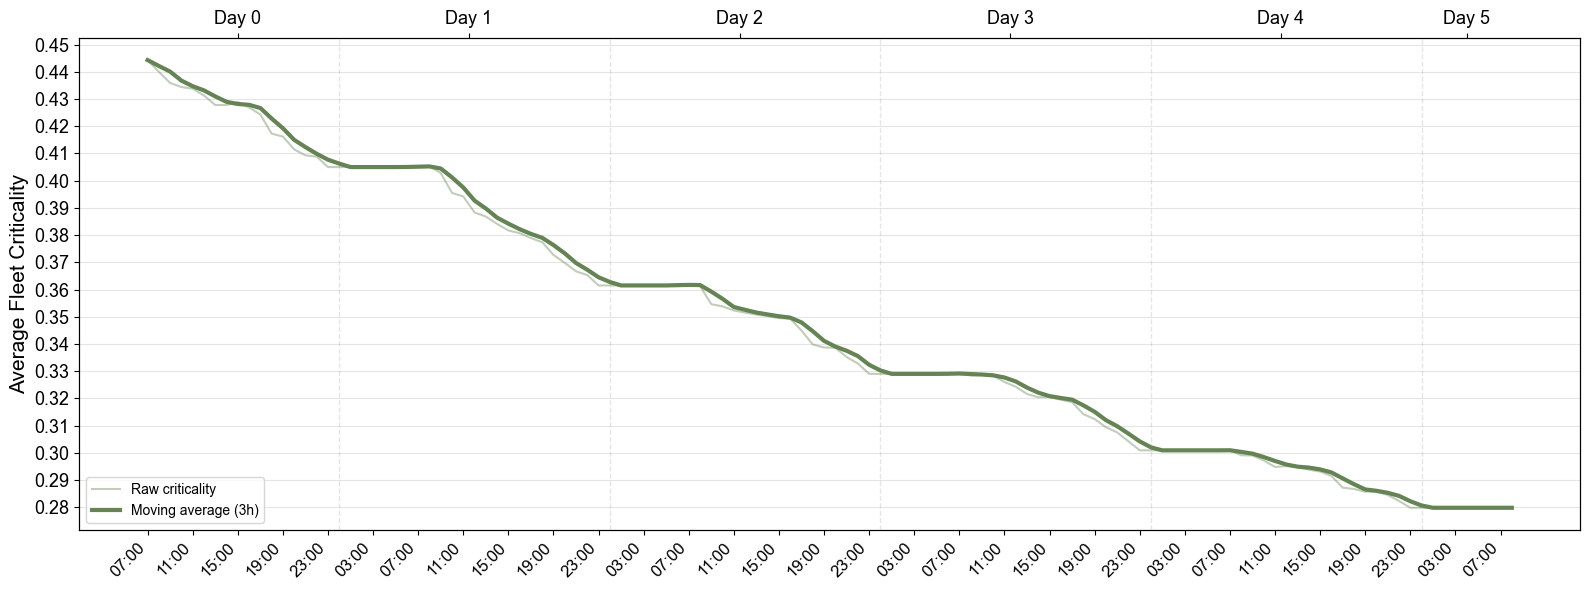

In [771]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---------------------------
# 1. PREPROCESSING
# ---------------------------
crit = hourly_data[["Day", "Hour", "Avg Bike Criticality"]].copy()

# Fix incorrect hour value "24" → Hour 0 of CURRENT day
mask_24 = crit["Hour"] == 24
crit.loc[mask_24, "Hour"] = 0
# REMOVED: crit.loc[mask_24, "Day"] += 1 

# Re-sort cleanly
crit = crit.sort_values(["Day", "Hour"]).reset_index(drop=True)

# ---------------------------
# 2. MOVING AVERAGE
# ---------------------------
window = 3
crit["MA"] = crit["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
crit["hour_label"] = crit["Hour"].astype(str).str.zfill(2) + ":00"

# ---------------------------
# 3. IDENTIFY DAY BOUNDARIES (FIXED)
# ---------------------------
# Find indices where the day changes
day_change_idx = crit.index[crit["Day"].ne(crit["Day"].shift())].tolist()

# FIX: Remove the "- 0.5". This places the line exactly on the "00:00" data point.
boundary_positions = day_change_idx[1:]

day_centers = []
day_labels = []
for day_val in crit["Day"].unique():
    idxs = crit.index[crit["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(day_val)}")

# ---------------------------
# 4. PLOTTING
# ---------------------------
x = crit.index 

fig, ax = plt.subplots(figsize=(16, 6))
line_color = "#658354"

# Raw values
ax.plot(x, crit["Avg Bike Criticality"], alpha=0.4, 
        label="Raw criticality", color=line_color)

# Moving average
ax.plot(x, crit["MA"], linewidth=3, color=line_color, 
        label=f"Moving average ({window}h)")

# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)

# ---------------------------
# GRANULAR Y-AXIS SETTINGS
# ---------------------------
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.01))
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.2, color='gray')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')

# Axis labels
ax.set_ylabel("Average Fleet Criticality", fontsize=15)
ax.set_xlabel("", fontsize=14)

# Tick frequency logic
step = max(1, len(crit) // 25)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(crit["hour_label"].iloc[::step], 
                   rotation=45, ha="right", fontsize=12)

ax.tick_params(axis='y', labelsize=13)

# ---------------------------
# 5. SECONDARY AXIS (Day Labels)
# ---------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=13)
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")

plt.savefig("average_fleet_criticality.svg")

ax.legend()
fig.tight_layout()
plt.show()

### 3.1.2 Map showing average criticality of all stations

In [772]:

# Extract numeric station id from "S0", "S1", ...
station_hourly_activity_df["id"] = (
    station_hourly_activity_df["Station ID"]
    .astype(str)
    .str.extract(r"S(\d+)")
    .astype(int)
)

# --- Compute per-row share of capacity that is broken ---
# guard against capacity = 0 just in case
station_hourly_activity_df["broken_share"] = (
    station_hourly_activity_df["Unusable Bikes"] /
    station_hourly_activity_df["Capacity"].replace(0, np.nan)
)

# ---------------------------
# Average maintenance criticality AND avg % broken per station
# ---------------------------
crit_per_station = (
    station_hourly_activity_df
    .groupby("id", as_index=False)
    .agg(
        avg_maint_crit=("Avg Maintenance Criticality", "mean"),
        avg_broken_share=("broken_share", "mean")   # this is 0–1
    )
)

# Merge with coordinates from stations_df (must already have lat/lon)
stations_crit = stations_df.merge(crit_per_station, on="id", how="left")
stations_crit["avg_maint_crit"] = stations_crit["avg_maint_crit"].fillna(0.0)
stations_crit["avg_broken_share"] = stations_crit["avg_broken_share"].fillna(0.0)

center_lat = stations_crit["lat"].mean()
center_lon = stations_crit["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# simple color mapping based on maintenance criticality
def crit_color(c):
    if c >= 0.6:
        return "red"
    elif c >= 0.5:
        return "orange"
    elif c >= 0.4:
        return "yellow"
    else:
        return "green"

for _, row in stations_crit.iterrows():
    c = row["avg_maint_crit"]
    broken_pct = row["avg_broken_share"] * 100  # turn into %

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,  # could also scale with broken_pct if you like
        fill=True,
        fill_opacity=0.8,
        color=crit_color(c),
        fill_color=crit_color(c),
        popup=(
            f"Station S{row['id']}<br>"
            f"Avg maint. criticality: {c:.3f}<br>"
            f"Avg broken: {broken_pct:.1f}% of capacity"
        ),
    ).add_to(m)

m.save(f"station_criticality_map_S{seed}_A{alpha_value}.html")


## 3.2 Service rate computation

In [773]:
# --- Existing: per-station requests & successes ---
trip_requests_counts = (
    trip_requests_df["Station ID"]
    .value_counts()
    .reset_index()
)
trip_requests_counts.columns = ["Station ID", "num_requests"]
print("Number of requests:", trip_requests_counts["num_requests"].sum())

trip_requests_df["successful_trip"] = trip_requests_df["Failure Reason"].isna()

successful_trip_counts = (
    trip_requests_df[trip_requests_df["successful_trip"]]
    .groupby("Station ID")
    .size()
    .reset_index(name="num_successful_trips")
)

trip_summary = trip_requests_counts.merge(
    successful_trip_counts, on="Station ID", how="left"
)
trip_summary["num_successful_trips"] = (
    trip_summary["num_successful_trips"].fillna(0).astype(int)
)

congestion_col = "Long Congestions"   # column in hourly_data

# total long congestions in the whole system
total_long_congestions = hourly_data[congestion_col].sum()

# total successful trips in the whole system
total_successful = trip_requests_df["successful_trip"].sum()

# subtract congestion from successful
effective_total_successful = max(
    total_successful - total_long_congestions, 0
)

total_requests = len(trip_requests_df)

service_rate_system = (
    effective_total_successful / total_requests if total_requests > 0 else 0
)

print(f"Total Long Congestions: {total_long_congestions}")
print(f"Effective successful trips: {effective_total_successful}")
print(f"Service rate (adjusted): {service_rate_system:.2%}")


Number of requests: 15720
Total Long Congestions: 603
Effective successful trips: 14031
Service rate (adjusted): 89.26%


# 4 Failed events

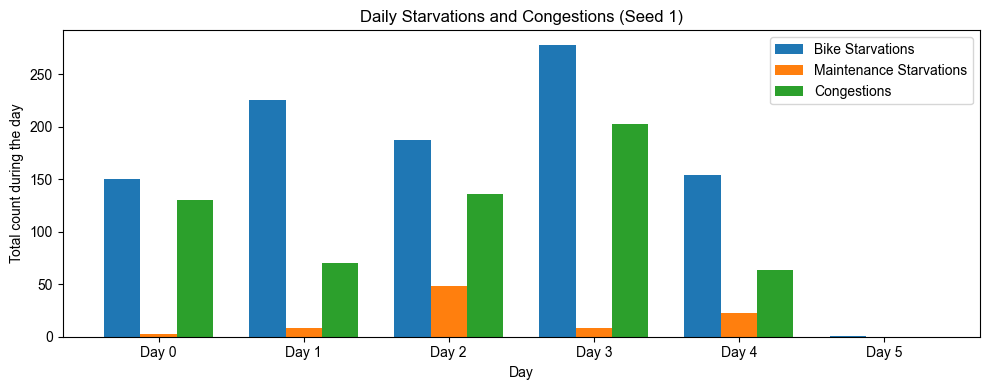

In [774]:
daily = ( hourly_data.groupby(["Seed", "Day"]) 
         .agg({ "Bike Starvations": "sum", "Long Congestions": "sum", "Short Congestions": "sum", "Maintenance Starvations": "sum" }) 
         .reset_index() ) # Total congestions per day 

daily["Congestions"] = daily["Long Congestions"]

# === PLOT PER SEED: 3 bars side-by-side per DAY ===
for seed, g in daily.groupby("Seed"):
    
    # DAY (unique days only)
    days = g["Day"].values
    
    bike_starv  = g["Bike Starvations"].values
    maint_starv = g["Maintenance Starvations"].values
    cong        = g["Long Congestions"].values #+ g["Short Congestions"].values
    
    x = np.arange(len(days))   # 0,1,2,... positions
    width = 0.25               # narrower bars

    plt.figure(figsize=(10,4))

    plt.bar(x - width, bike_starv,  width=width, label="Bike Starvations")
    plt.bar(x,         maint_starv, width=width, label="Maintenance Starvations")
    plt.bar(x + width, cong,        width=width, label="Congestions")

    plt.xlabel("Day")
    plt.ylabel("Total count during the day")
    plt.title(f"Daily Starvations and Congestions (Seed {seed})")

    plt.xticks(x, [f"Day {d}" for d in days])
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4.1 Bike starvation

### 4.1.1 Plot for mean over all hours of simulation horizon

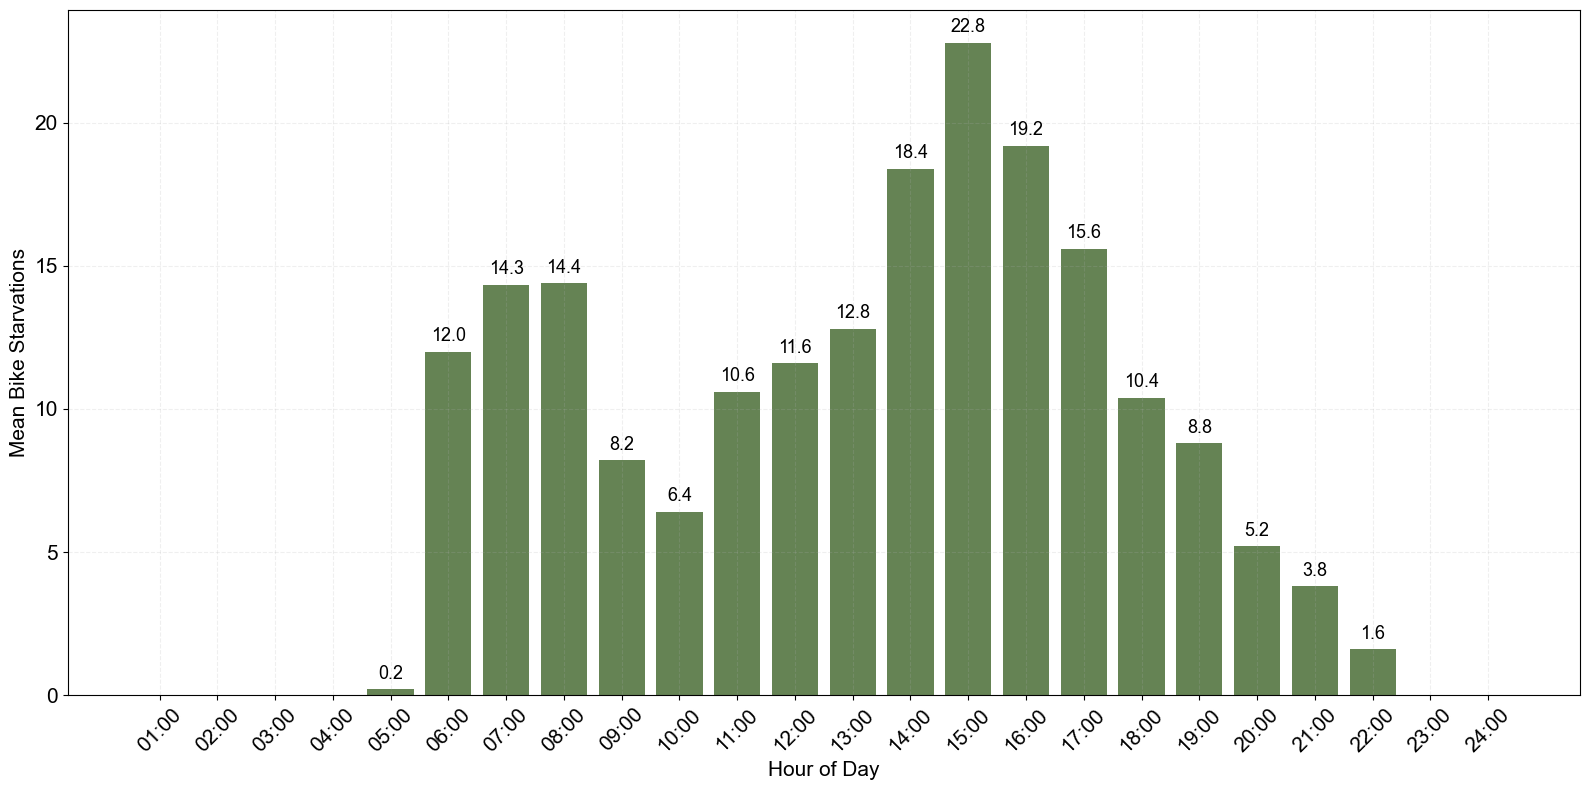

In [775]:
# 1. Sum maintenance starvations for each (Day, Hour) pair
starv_by_day_hour = (
    hourly_data.groupby(["Day", "Hour"])["Bike Starvations"]
    .sum()
    .reset_index()
)

# 2. Compute mean maintenance starvations per hour across days
mean_hourly_starv = (
    starv_by_day_hour.groupby("Hour")["Bike Starvations"]
    .mean()
    .reset_index()
)

# Extract hours and mean values
hours = mean_hourly_starv["Hour"].tolist()
starv_vals = mean_hourly_starv["Bike Starvations"].tolist()

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# 3. Create plot
plt.figure()

# Bar plot
bar_color = "#658354"    # Matplotlib default blue
plt.bar(hour_labels, starv_vals, color=bar_color, alpha=1.0)

# Line plot overlay
#plt.plot(hour_labels, starv_vals, marker='o')

# Labels and title
plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Bike Starvations", fontsize=font_size)


threshold = 0.10 * max(starv_vals)

# Label values on bars
for h, v in zip(hour_labels, starv_vals):
    if v != 0.0:
        plt.text(h, v + threshold * 0.1,
                f"{v:.1f}",
                ha='center', va='bottom',
                color='black', fontsize=value_size)

plt.xticks(rotation=45, fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)
plt.savefig("mean_bike_starvations_per_hour.svg")

plt.tight_layout()
plt.show()


## 4.2 Congestion

### 4.2.1 Plot mean over all hours of simulation horizon (24h agg)

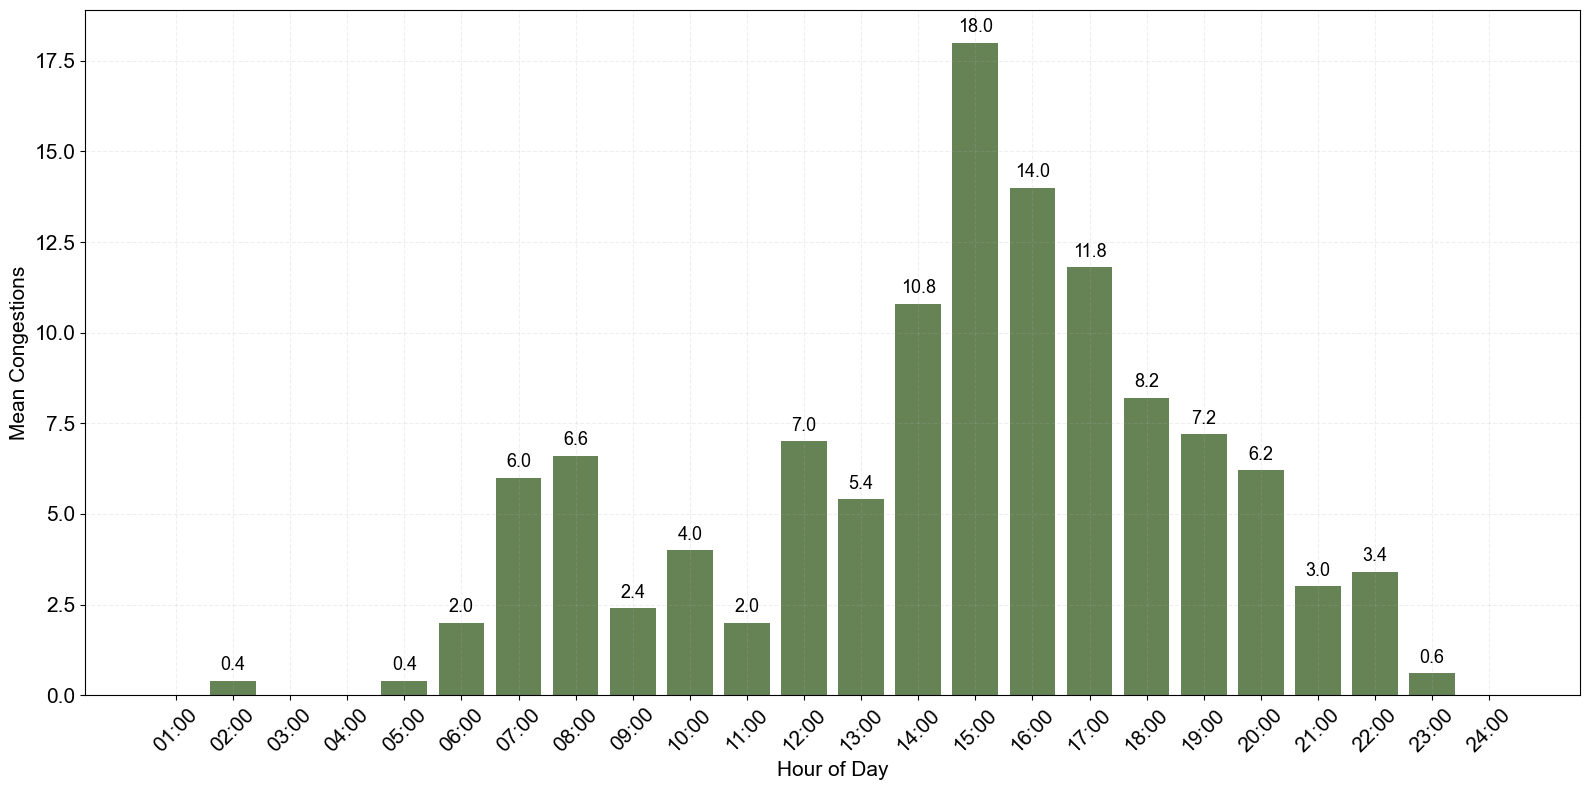

In [776]:
# 1. Sum maintenance starvations for each (Day, Hour) pair
starv_by_day_hour = (
    hourly_data.groupby(["Day", "Hour"])["Long Congestions"]
    .sum()
    .reset_index()
)

# 2. Compute mean maintenance starvations per hour across days
mean_hourly_cong = (
    starv_by_day_hour.groupby("Hour")["Long Congestions"]
    .mean()
    .reset_index()
)

# Extract hours and mean values
hours = mean_hourly_cong["Hour"].tolist()
starv_vals = mean_hourly_cong["Long Congestions"].tolist()

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# 3. Create plot
plt.figure()

# Bar plot
bar_color = "#658354"    # Matplotlib default blue
plt.bar(hour_labels, starv_vals, color=bar_color, alpha=1.0)

# Line plot overlay
#plt.plot(hour_labels, starv_vals, marker='o')

# Labels and title
plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Congestions", fontsize=font_size)


threshold = 0.10 * max(starv_vals)

# Label values on bars
for h, v in zip(hour_labels, starv_vals):
    if v != 0.0:
        # Place label ABOVE the bar
        plt.text(h, v + threshold * 0.1,
                f"{v:.1f}",
                ha='center', va='bottom',
                color='black', fontsize=value_size)

plt.xticks(rotation=45, fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)

plt.savefig("mean_long_congestions_per_hour.svg")
plt.tight_layout()
plt.show()

### 4.2.2 XX

# 4.3 Maintenance violations

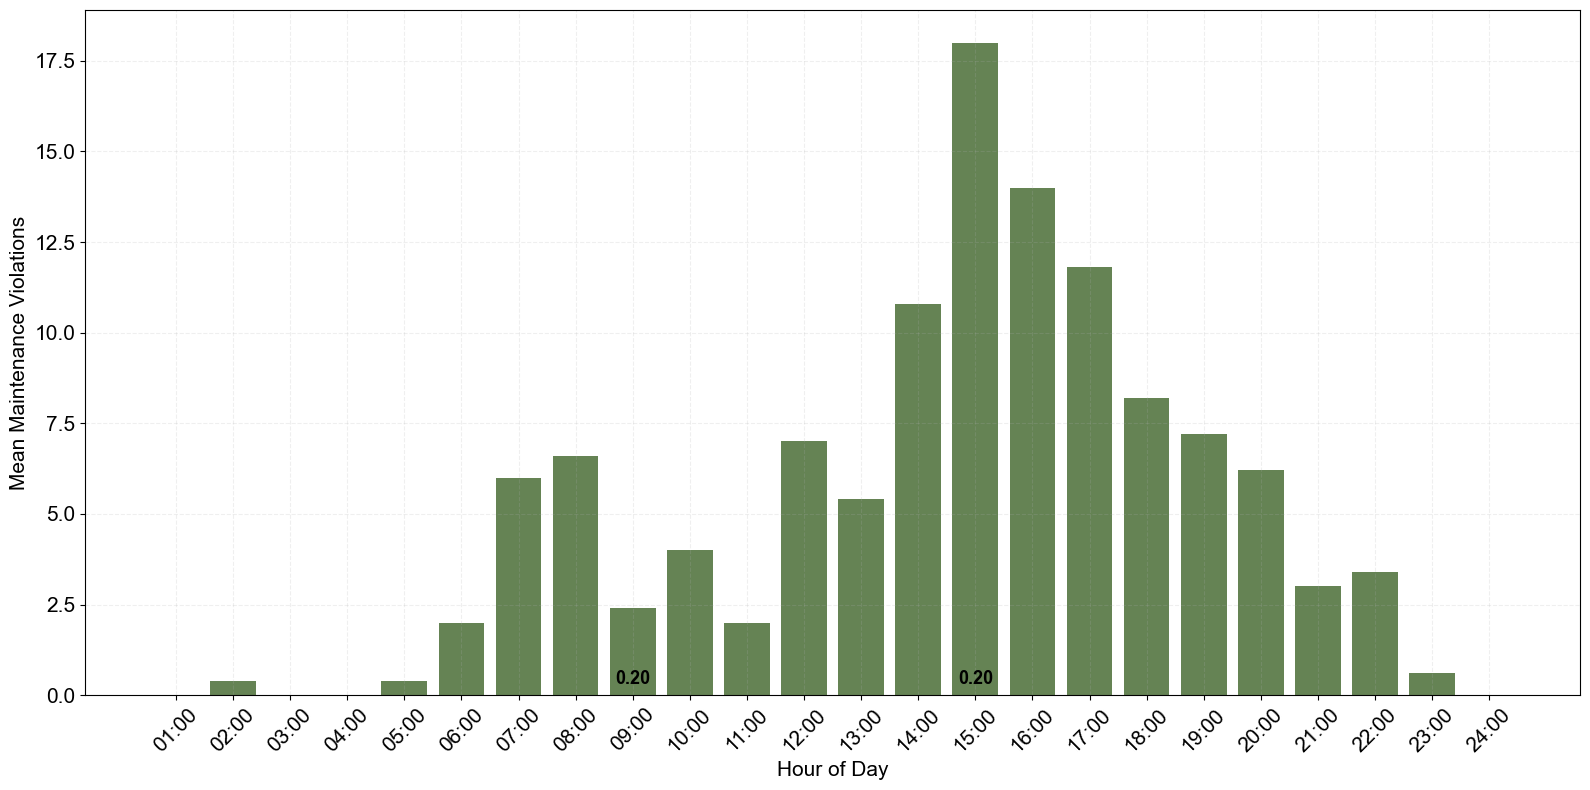

In [777]:
# 1. Sum maintenance starvations for each (Day, Hour) pair
maintV_by_day_hour = (
    hourly_data.groupby(["Day", "Hour"])["Maintenance Violations"]
    .sum()
    .reset_index()
)

# 2. Compute mean maintenance starvations per hour across days
mean_hourly_maintV = (
    maintV_by_day_hour.groupby("Hour")["Maintenance Violations"]
    .mean()
    .reset_index()
)

# Extract hours and mean values
hours = mean_hourly_maintV["Hour"].tolist()
maintV_vals = mean_hourly_maintV["Maintenance Violations"].tolist()

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# 3. Create plot
plt.figure()

# Bar plot
bar_color = "#658354"    # Matplotlib default blue
plt.bar(hour_labels, starv_vals, color=bar_color, alpha=1.0)

# Line plot overlay
#plt.plot(hour_labels, starv_vals, marker='o')

# Labels and title
plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Maintenance Violations", fontsize=font_size)


#threshold = 0.10 * max(maintV_vals)

# Value labels OUTSIDE bars
for h, v in zip(hour_labels, maintV_vals):
    if v > 0.0:
        plt.text(
            h, 
            v,                # Y-position: Top of the bar
            f"{v:.2f}",       # Changed to .2f for consistency (or keep .1f if preferred)
            ha='center', 
            va='bottom',      # Align bottom of text to value
            color='black', 
            fontsize=value_size,
            fontweight='bold'
        )
plt.xticks(rotation=45, fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)

plt.savefig("mean_maintenance_violations_per_hour.svg")
plt.tight_layout()
plt.show()

## 4.4 Maintenance starvations

### 4.4.1 Accumulated for different parts of day

In [778]:
# Define which hours count as "morning" and "afternoon"
# Adjust these sets to match your thesis definition
morning_hours   = [7, 8, 9, 10]       # example: 07:00–11:00
early_mid_day_hours  = [11, 12]    # example: 11:00–15:00
late_mid_day_hours  = [13, 14]    # example: 11:00–15:00
afternoon_hours = [15, 16, 17, 18]    # example: 15:00–19:00
evening_hours   = [19, 20, 21, 22]    # example: 19:00–23:00

# Aggregate maintenance starvations by hour of day (across all days)
maint_by_hour = (
    hourly_data
    .groupby("Hour")["Maintenance Starvations"]
    .sum()
    .rename("MaintStarvations")
)

morning_maint   = maint_by_hour.loc[morning_hours].sum()
early_mid_day_maint   = maint_by_hour.loc[early_mid_day_hours].sum()
late_mid_day_maint   = maint_by_hour.loc[late_mid_day_hours].sum()
afternoon_maint = maint_by_hour.loc[afternoon_hours].sum()
evening_maint   = maint_by_hour.loc[evening_hours].sum()


if afternoon_maint > 0:
    ratio = morning_maint / afternoon_maint
else:
    ratio = np.nan

print("Morning maintenance starvations:", morning_maint)
print("Early mid-day maintenance starvations:", early_mid_day_maint)
print("Late mid-day maintenance starvations:", late_mid_day_maint)
print("Afternoon maintenance starvations:", afternoon_maint)
print("Evening maintenance starvations:", evening_maint)
print("Ratio (morning / afternoon):", ratio)

Morning maintenance starvations: 32
Early mid-day maintenance starvations: 23
Late mid-day maintenance starvations: 9
Afternoon maintenance starvations: 18
Evening maintenance starvations: 8
Ratio (morning / afternoon): 1.7777777777777777


### 4.4.2 Plot for mean over all hours of simulation horizon

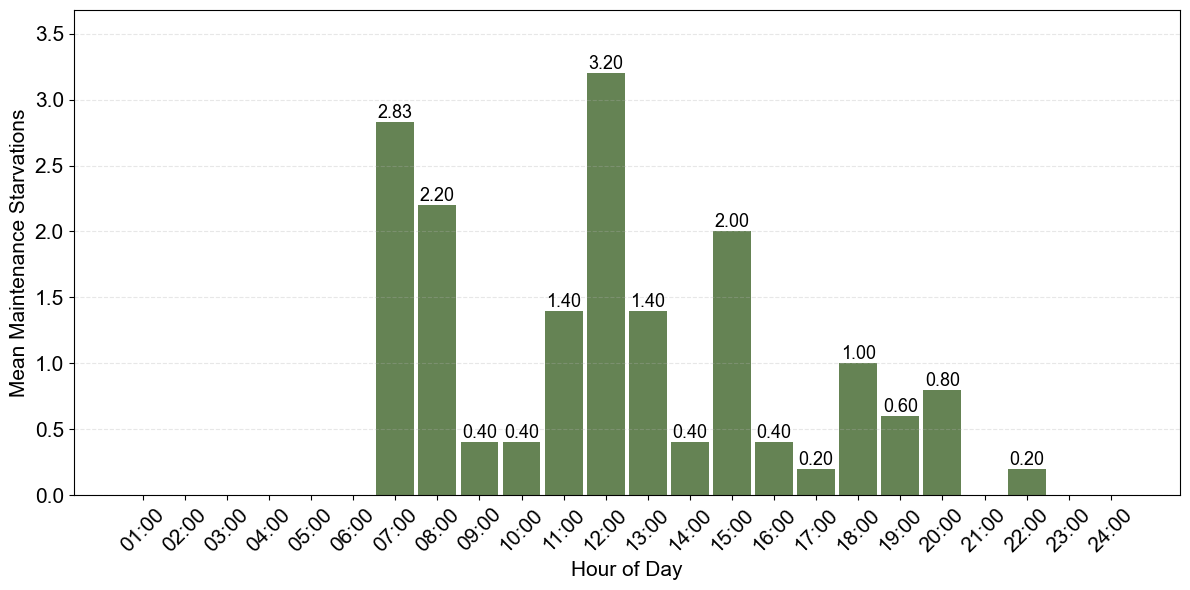

In [779]:
# 1. Sum maintenance starvations for each (Day, Hour) pair
maint_by_day_hour = (
    hourly_data.groupby(["Day", "Hour"])["Maintenance Starvations"]
    .sum()
    .reset_index()
)

# 2. Compute mean maintenance starvations per hour across days
mean_hourly_maint = (
    maint_by_day_hour.groupby("Hour")["Maintenance Starvations"]
    .mean()
    .reset_index()
)

# Extract hours and mean values
hours = mean_hourly_maint["Hour"].tolist()
maint_vals = mean_hourly_maint["Maintenance Starvations"].tolist()

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# ==========================================
# 2. PLOTTING
# ==========================================

plt.figure(figsize=(12, 6)) # Added figsize for better proportions
ax = plt.gca()

# Bar plot
bar_color = "#658354"
bars = plt.bar(hour_labels, maint_vals, color=bar_color, alpha=1.0, width=0.9)

# Labels and title
plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Maintenance Starvations", fontsize=font_size)

# Value labels OUTSIDE bars
for h, v in zip(hour_labels, maint_vals):
    if v > 0.0: # Check if value is significant
        plt.text(
            h, 
            v,                # Y-position: Top of the bar
            f"{v:.2f}", 
            ha='center', 
            va='bottom',      # Align bottom of text to the value point
            color='black',    # Dark color for visibility on white background
            fontsize=value_size 
        )

# Adjust Y-axis limit to make room for labels on top
if maint_vals:
    plt.ylim(0, max(maint_vals) * 1.15) 

plt.yticks(fontsize=font_size)
plt.xticks(rotation=45, fontsize=font_size)
plt.grid(axis='y', linestyle='--', alpha=0.3) # Grid usually looks cleaner on y-axis only for bars

plt.tight_layout()
plt.savefig("mean_maintenance_starvations_per_hour.svg")
plt.show()

### 4.4.3 XXXXX 

## 4.5 Stacked barchart of long congestions and bike starvations

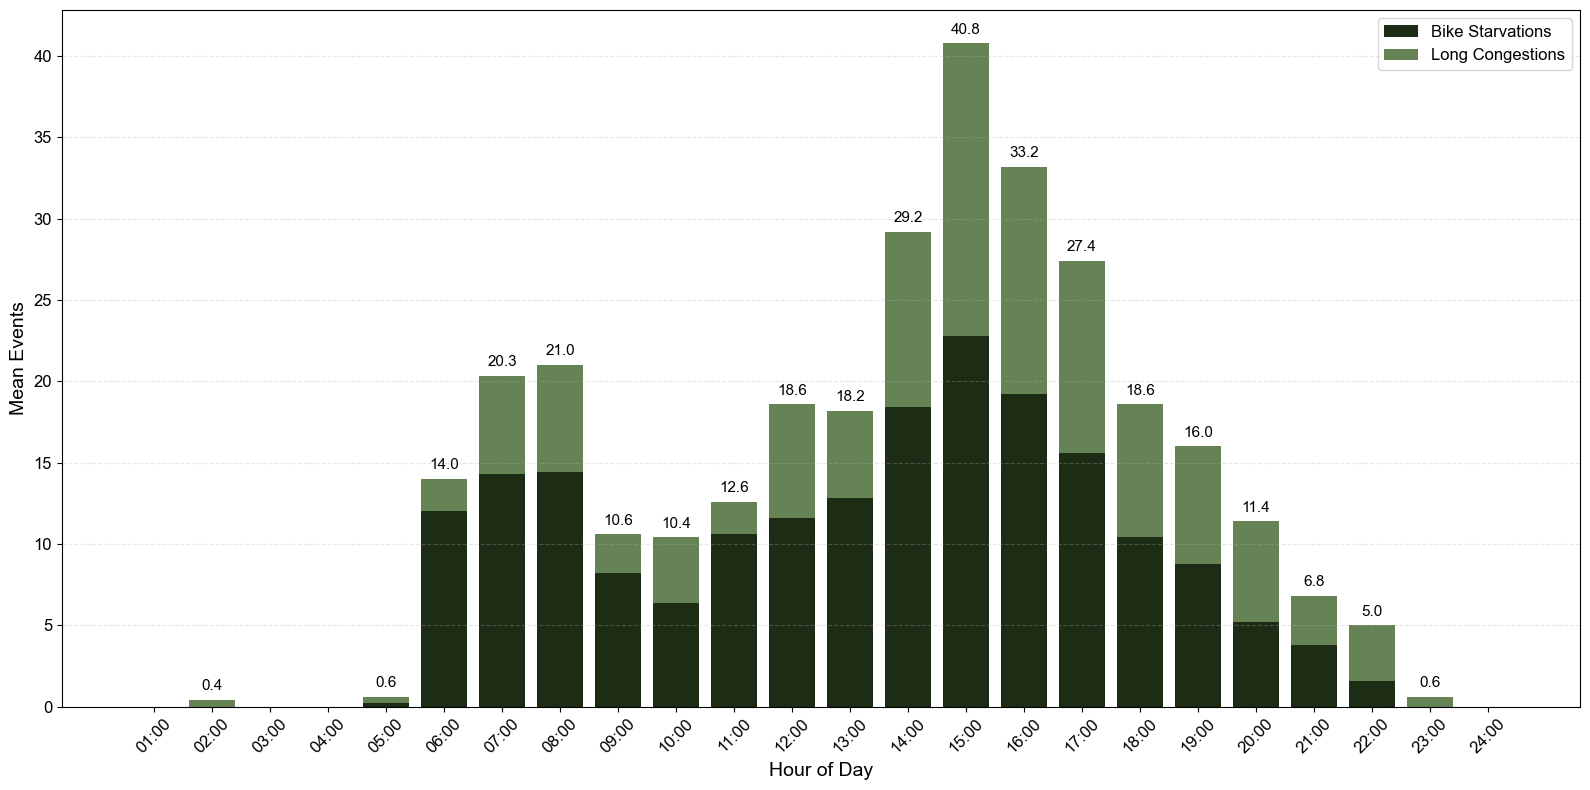

In [780]:

# ---------------------------
# 1. Data Processing
# ---------------------------

# Sum both metrics for each (Day, Hour) pair
hourly_sums = (
    hourly_data.groupby(["Day", "Hour"])[["Bike Starvations", "Long Congestions"]]
    .sum()
    .reset_index()
)

# Compute mean per hour across all days
mean_hourly = (
    hourly_sums.groupby("Hour")[["Bike Starvations", "Long Congestions"]]
    .mean()
    .reset_index()
)

# Extract lists
hours = mean_hourly["Hour"].tolist()
starv_vals = mean_hourly["Bike Starvations"].tolist()
cong_vals = mean_hourly["Long Congestions"].tolist()

# Calculate total height for labeling and axis limits
total_vals = [s + c for s, c in zip(starv_vals, cong_vals)]

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# ---------------------------
# 2. Plotting
# ---------------------------

plt.figure()

# Define colors
color_cong = "#658354"  # Sage Green
color_starv = "#1D2C15"   # Muted Orange/Terra cotta

# Plot Bottom Bar (Starvations)
plt.bar(hour_labels, starv_vals, color=color_starv, label="Bike Starvations", alpha=1.0)

# Plot Top Bar (Congestions) - use 'bottom' parameter to stack
plt.bar(hour_labels, cong_vals, bottom=starv_vals, color=color_cong, label="Long Congestions", alpha=1.0)

# ---------------------------
# 3. Formatting
# ---------------------------

plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Mean Events", fontsize=14)
plt.legend(fontsize=12)

# Calculate threshold for label spacing
threshold = 0.01 * max(total_vals) if max(total_vals) > 0 else 0.1

# Label the TOTAL height on top of the stack
for h, total in zip(hour_labels, total_vals):
    if total > 0.0:
        plt.text(h, total + threshold,
                 f"{total:.1f}",
                 ha='center', va='bottom',
                 color='black', fontsize=11)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("stacked_starvations_congestions.svg")
plt.show()

# 5 Vehicle insight

In [781]:
# print the total number of visitns for vehicles and how many unique stations were visited
total_visits = vehicle_df.shape[0]
unique_stations = vehicle_df["Station ID"].nunique()
print(f"Total visits: {total_visits}, Unique stations visited: {unique_stations}")


Total visits: 451, Unique stations visited: 57


In [782]:
# Extract numeric id: "S35" → 35
vehicle_df["id"] = vehicle_df["Station ID"].str.extract(r"S(\d+)").astype(int)

# Count visits per station id
station_counts = (
    vehicle_df
        .groupby("id")
        .size()
        .reset_index(name="num_visits")
)

# Join on integer id
stations_with_visits = stations_df.merge(station_counts, on="id", how="left")

# Fill stations that never appear in visits
stations_with_visits["num_visits"] = stations_with_visits["num_visits"].fillna(0).astype(int)

stations_with_visits.head(70)


,id,location,is_depot,capacity,num_bikes,leave_intensities,leave_intensities_stdev,arrive_intensities,arrive_intensities_stdev,move_probabilities,lat,lon,num_visits
0,0,"[63.40772802863199, 10.39705323440262]",False,21,10,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.2, 0.8, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.400000000000...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8000000...","[[[0.014925373134328358, 0.014925373134328358,...",63.407728,10.397053,4
1,1,"[63.414746566093925, 10.397386363673064]",False,15,7,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.2, 0.4, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.6, 0.0, 0.2,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[[0.014925373134328358, 0.014925373134328358,...",63.414747,10.397386,7
2,2,"[63.436025749373755, 10.430998463879718]",False,24,12,"[[0.0, 0.0, 0.0, 0.0, 0.2, 1.8, 0.4, 0.2, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 2.22...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.400000000000...","[[[0.014925373134328358, 0.014925373134328358,...",63.436026,10.430998,1
3,3,"[63.42126270770024, 10.386516005020496]",False,18,8,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.4, 0.0, 0.4,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.7999999999999999,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 1.4, 1.6, 0.2, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 1.95...","[[[0.014925373134328358, 0.014925373134328358,...",63.421263,10.386516,3
4,4,"[63.43337733865644, 10.401074857528158]",False,18,8,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 1.0, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 2.2, 0.8, 1.2, 0.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 2.31...","[[[0.014925373134328358, 0.014925373134328358,...",63.433377,10.401075,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,62,"[63.427896581278105, 10.403341750766884]",False,26,13,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 2.8, 1.8, 1.2,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.8330302779823362,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 1.0, 1.2, 1.4, 1.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 1.54...","[[[0.014925373134328358, 0.014925373134328358,...",63.427897,10.403342,22
63,63,"[63.42994558007871, 10.391905842869932]",False,28,14,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.2, 2.0, 1.0, 1.8,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.1661903789690602,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 3.0, 1.6, 3.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 0.74...","[[[0.014925373134328358, 0.014925373134328358,...",63.429946,10.391906,21
64,64,"[63.43527713641004, 10.405813604593277]",False,13,6,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.400000000000...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.4, 1.0, 0.0, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.4966629547095764,...","[[[0.014925373134328358, 0.014925373134328358,...",63.435277,10.405814,4
65,65,"[63.43660495943216, 10.425844341516495]",False,25,13,"[[0.0, 0.0, 0.0, 0.0, 1.6, 5.4, 1.2, 1.0, 0.4,...","[[0.0, 0.0, 0.0, 0.0, 1.854723699099141, 2.576...","[[0.0, 0.0, 0.0, 0.0, 0.2, 0.4, 0.0, 0.4, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 0.48...","[[[0.014925373134328358, 0.014925373134328358,...",63.436605,10.425844,5


## 5.1 Unique stations visited per hour

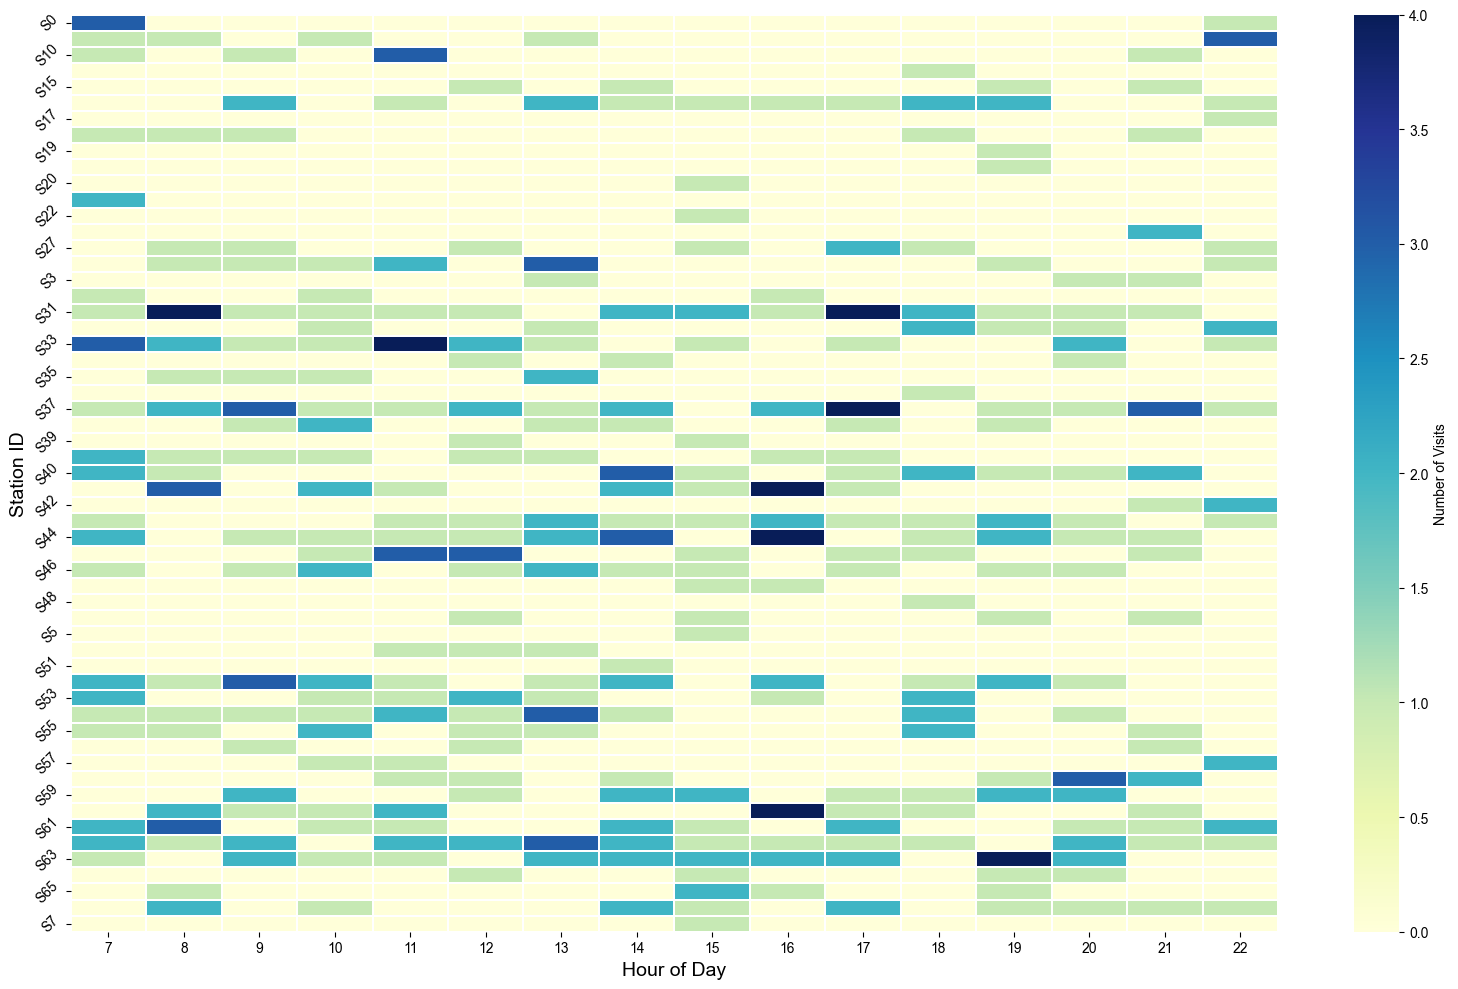

In [783]:
df = vehicle_df  # your visit data

# Count visits per station per hour
visits_matrix = (
    df.groupby(["Station ID", "Hour"])
      .size()
      .reset_index(name="visits")
)

# Pivot to station x hour matrix
heatmap_data = visits_matrix.pivot(index="Station ID", columns="Hour", values="visits")

# Replace NaN with 0
heatmap_data = heatmap_data.fillna(0)

plt.figure(figsize=(16,10))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.01,
    cbar_kws={"label": "Number of Visits"}
)

plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Station ID", fontsize=14)

plt.xticks()
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.2 Plot over visit frequency on map

In [784]:
def visit_color(n):
    if n == 0:
        return "light green"
    elif 1 <= n <= 5:
        return "#f7f148"
    elif 6 <= n <= 15:
        return "#f3903f"
    elif 16 <= n <= 25:
        return "#ed683c"
    else:
        return "#ce0011"




# Center map on mean lat/lon of all stations
center_lat = stations_with_visits["lat"].mean()
center_lon = stations_with_visits["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# (optional) show all stations, or only top N
#top_stations = stations_with_visits.sort_values("num_visits", ascending=False).head(50)
top_stations = stations_with_visits  # <- all
print(top_stations["num_visits"].head(70))

max_visits = top_stations["num_visits"].max()
min_radius = 5
max_radius = 20 if max_visits > 0 else 6

for _, row in top_stations.iterrows():
    n = row["num_visits"]
    # scale radius with visits, but keep within a nice range
    radius = min_radius if max_visits == 0 else (
        min_radius + (n / max_visits) * (max_radius - min_radius)
    )

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        fill=True,
        color=visit_color(n),
        fill_color=visit_color(n),
        fill_opacity=0.8,
        popup=f"Station S{row['id']}<br>Visits: {n}",
    ).add_to(m)

m.save(f"trondheim_map_S{seed}_A{alpha_value}.html")

0      4
1      7
2      1
3      3
4      9
      ..
62    22
63    21
64     4
65     5
66    12
Name: num_visits, Length: 67, dtype: int64


## 5.3 Vehicle maintenance allocation

C:\Users\Minamsj\AppData\Local\Temp\ipykernel_29296\3674163441.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_data = hourly_data.groupby("Seed", group_keys=False).apply(add_ma)


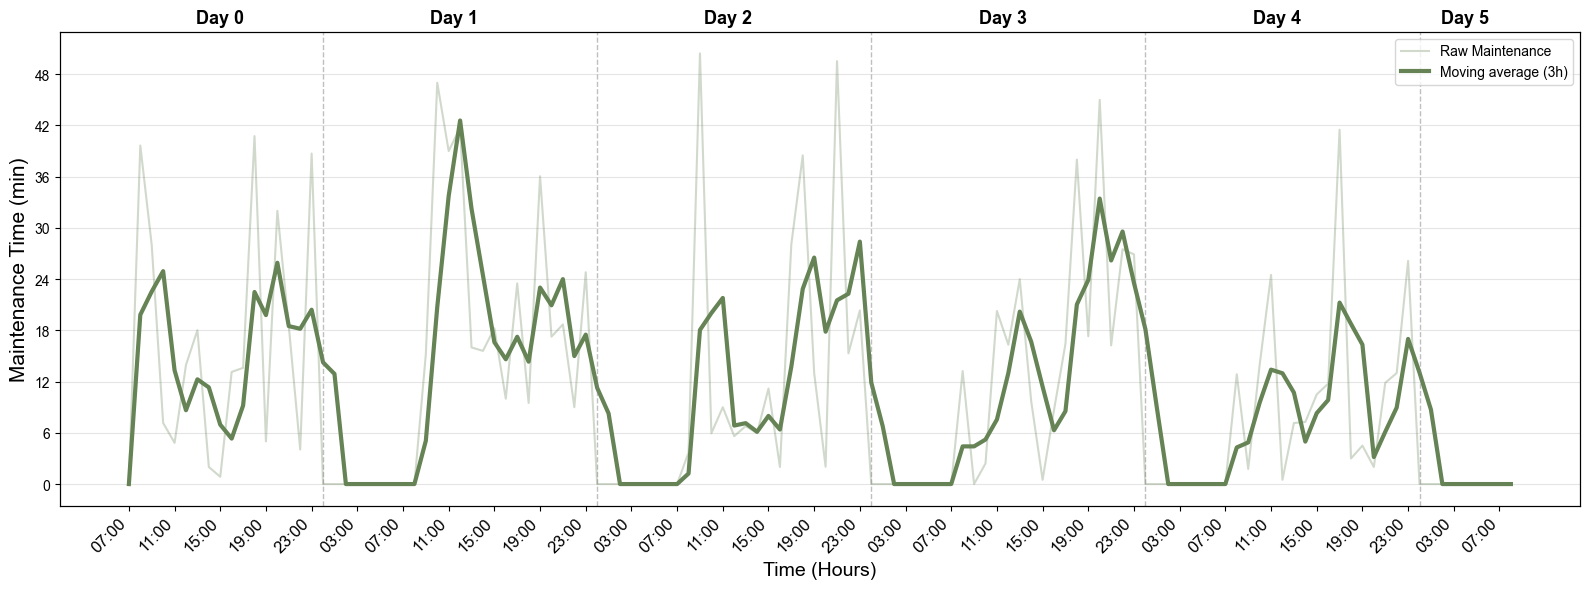

In [787]:


# Assume 'hourly_data' is loaded.
# Columns: 'Seed', 'Time (minutes)', 'Maintenance Time (minutes)', 'Day', 'Hour'

# 1. SORT DATA
hourly_data = hourly_data.sort_values(["Seed", "Time (minutes)"])

# 2. CALCULATE MOVING AVERAGE (Global apply)
def add_ma(group):
    m = group["Maintenance Time (minutes)"]
    group["Maintenance_MA"] = m.rolling(window=3, min_periods=1).mean()
    return group

hourly_data = hourly_data.groupby("Seed", group_keys=False).apply(add_ma)

# === PLOT LOOP ===
for seed, g in hourly_data.groupby("Seed"):
    
    # Reset index so X is 0, 1, 2... This makes aligning days/hours much easier
    g = g.reset_index(drop=True)
    
    # Create Label for bottom axis
    g["hour_label"] = g["Hour"].astype(str).str.zfill(2) + ":00"

    # --- IDENTIFY DAY BOUNDARIES ---
    # Find indices where the day changes (Day i != Day i-1)
    day_change_idx = g.index[g["Day"].ne(g["Day"].shift())].tolist()
    
    # We skip the very first index (0) so we don't draw a line at the start
    boundary_positions = day_change_idx[1:]

    # --- CALCULATE DAY CENTERS (For Top Axis) ---
    day_centers = []
    day_labels = []
    for day_val in g["Day"].unique():
        idxs = g.index[g["Day"] == day_val]
        if len(idxs) > 0:
            center = (idxs[0] + idxs[-1]) / 2
            day_centers.append(center)
            day_labels.append(f"Day {int(day_val)}")

    # --- PLOTTING ---
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Use the reference color (Olive Green)
    line_color = "#658354"
    x = g.index 

    # 1. Raw values (Low Alpha)
    ax.plot(x, g["Maintenance Time (minutes)"], alpha=0.3, 
            label="Raw Maintenance", color=line_color)

    # 2. Moving average (Thick line)
    ax.plot(x, g["Maintenance_MA"], linewidth=3, color=line_color, 
            label="Moving average (3h)")

    # 3. Vertical lines (Day boundaries)
    for pos in boundary_positions:
        ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    # --- Y-AXIS GRID & FORMATTING ---
    # Auto-adjust y-axis ticks to be granular but readable
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10)) 
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.2, color='gray')
    ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')
    
    ax.set_ylabel("Maintenance Time (min)", fontsize=15)
    ax.set_xlabel("Time (Hours)", fontsize=14)
    # --- BOTTOM X-AXIS (Hours) ---
    # Calculate step to prevent label overlap (e.g., every ~20th point)
    step = max(1, len(g) // 25)
    
    ax.set_xticks(list(x)[::step])
    ax.set_xticklabels(g["hour_label"].iloc[::step], 
                       rotation=45, ha="right", fontsize=12)

    # --- TOP X-AXIS (Day Labels) ---
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim()) # Sync limits exactly
    ax2.set_xticks(day_centers)
    ax2.set_xticklabels(day_labels, fontsize=13, fontweight='bold')
    
    # Ensure top ticks/labels are actually at the top
    ax2.xaxis.set_ticks_position("top")
    ax2.xaxis.set_label_position("top")
    # Hide the ticks (lines) themselves on the top, keep the text
    ax2.tick_params(axis='x', length=0) 

    ax.legend(loc="upper right", frameon=True)

    plt.savefig(f"maintenance_time_seed_{seed}.svg")
    plt.tight_layout()
    plt.show()

## 5.4 Total time spent on maintenance vs rebalancing
This graph shows 

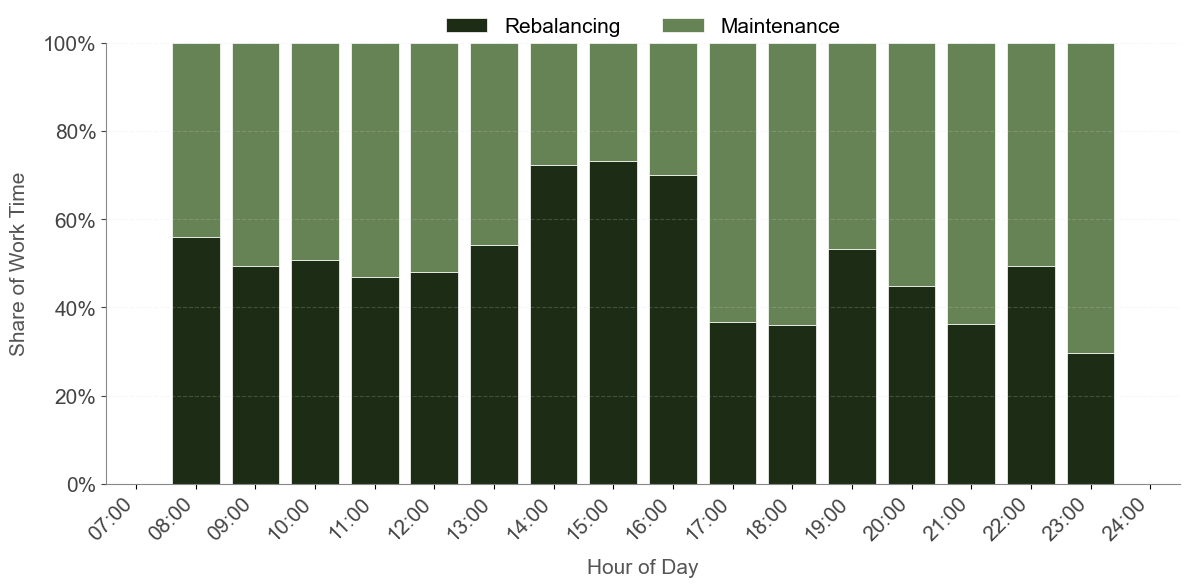

In [786]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================

# NOTE: Assuming 'hourly_data' is the dataframe you have loaded.
# Filter out hours before 7 AM
hourly_df_filtered = hourly_data[hourly_data['Hour'] >= 7].copy()

# Calculate raw minutes per hour
hourly_df_filtered['Rebalancing Time'] = (hourly_df_filtered['Bike Pickups'] + hourly_df_filtered['Bike Deliveries']) * 0.5
hourly_df_filtered['Maintenance Time'] = hourly_df_filtered['Maintenance Time (minutes)']

# Group by 'Hour' to find the average
daily_profile = hourly_df_filtered.groupby("Hour")[['Rebalancing Time', 'Maintenance Time']].mean()

# Re-calculate fractions
daily_profile['Total Activity'] = daily_profile['Rebalancing Time'] + daily_profile['Maintenance Time']
daily_profile['Fraction Rebalancing'] = daily_profile['Rebalancing Time'] / daily_profile['Total Activity']
daily_profile['Fraction Maintenance'] = daily_profile['Maintenance Time'] / daily_profile['Total Activity']

# Fill NaNs
daily_profile = daily_profile.fillna(0).sort_index()

# ==========================================
# 2. PLOTTING
# ==========================================

# Set global font family
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

colors = {'Reb': "#1D2C15", 'Maint': '#658354'} 

hours = daily_profile.index

# --- PLOT ---
ax.bar(hours, daily_profile['Fraction Rebalancing'],
       color=colors['Reb'], label='Rebalancing',
       width=0.8, edgecolor='white', linewidth=0.5)

ax.bar(hours, daily_profile['Fraction Maintenance'],
       bottom=daily_profile['Fraction Rebalancing'],
       color=colors['Maint'], label='Maintenance',
       width=0.8, edgecolor='white', linewidth=0.5)

# --- AESTHETICS ---

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

# Grid
ax.grid(True, which='major', axis='y', linestyle='--', color='#DDDDDD', zorder=0, alpha=0.2)
ax.grid(False, axis='x')

# X-Axis Ticks
ax.set_xticks(hours) # Set locations first

# ERROR FIXED HERE: Added int(h) inside the f-string
ax.set_xticklabels([f"{int(h):02d}:00" for h in hours], 
                   rotation=45, color='#444444', ha="right", fontsize=font_size)

# Y-Axis Ticks
ax.set_yticks(np.linspace(0, 1.0, 6)) # Set locations first
ax.tick_params(axis='y', colors='#444444', labelsize=font_size) # Set size via tick_params

# Format Y-axis as percentage
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

# Limits
ax.set_ylim(0, 1.0)
ax.set_xlim(hours.min()-0.5, hours.max()+0.5)

# Labels
ax.set_ylabel("Share of Work Time", fontsize=font_size, color='#555555', labelpad=10)
ax.set_xlabel("Hour of Day", fontsize=font_size, color='#555555', labelpad=10)

# Legend
ax.legend(frameon=False, fontsize=font_size, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)

plt.tight_layout()
plt.savefig("daily_worktime_profile.svg", bbox_inches='tight')
plt.show()